# Lens Picture

This notebook demonstrates the simulation and optimization of an optical system using the `diffinytrace` package.  
It was run in **Google Colab** to take advantage of GPU acceleration and Google Drive integration for saving results.


In [ ]:
%pip install diffinytrace.zip

Processing ./diffinytrace.zip
  Preparing metadata (setup.py) ... done
  Created wheel for diffinytrace: filename=diffinytrace-2.1-py3-none-any.whl size=87334 sha256=c1278baa545cc19929edb3a704302e74f3f196089d6942b79996d171cabe804a
  Stored in directory: /tmp/pip-ephem-wheel-cache-9vgo3gwe/wheels/db/ea/21/35eb070bb05c3b3e3b9b47ff193267b4ac5b0871240da78a7c
Successfully built diffinytrace
  Attempting uninstall: diffinytrace
    Found existing installation: diffinytrace 2.1
    Uninstalling diffinytrace-2.1:
      Successfully uninstalled diffinytrace-2.1


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


Mounted at /content/gdrive


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))
path = "results/results_final_lens_picture"

<>:75: SyntaxWarning: invalid escape sequence '\D'
<>:75: SyntaxWarning: invalid escape sequence '\D'
C:\Users\marti\AppData\Local\Temp\ipykernel_19656\1929737373.py:75: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(x, gaussian2, label=f'Gaussian centered at $\Delta x$')


num of conv points should probably be at least  336.0


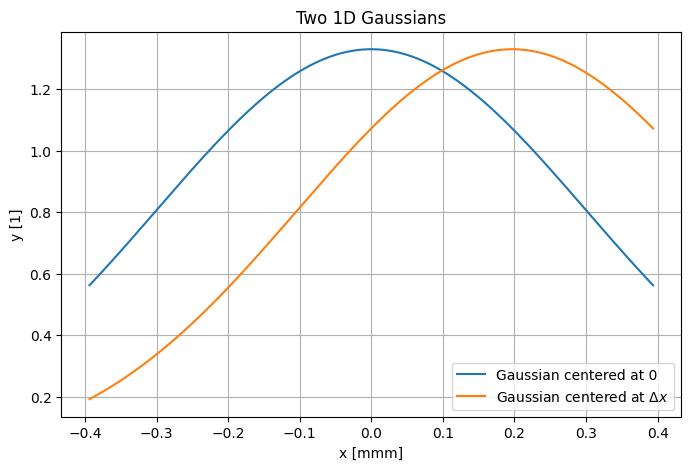

c:\Users\marti\anaconda3\envs\working\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0090, device='cuda:0', grad_fn=<SqrtBackward0>) 0.0089878548056
last_error (tensor(0.0090), tensor(0.0002), tensor(0.6737)) 0.008975779387142727
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0087, device='cuda:0', grad_fn=<SqrtBackward0>) 0.0087495826372
last_error (tensor(0.0087), tensor(0.0002), tensor(0.6768)) 0.008727533446428886
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0073, device='cuda:0', grad_fn=<SqrtBackward0>) 0.0072576994095
last_error (tensor(0.0073), tensor(0.0001), tensor(0.6990)) 0.00735192617931211
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0065, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00655597220598
last_error (tensor(0.0066), tensor(0.0001), tensor(0.7119)) 0.0065942493651957685
END
BEGIN: opti after refine: coeff shape: torch.Size([34, 34])
last_merit tensor(0.0059, d

100%|██████████| 1000/1000 [04:00<00:00,  4.16it/s]


Data saved to results/results_final_lens_picture/lens_picture//results_classical/results_dict.pkl
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
last_merit tensor(0.0078, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00778826830637
last_error (tensor(0.0090), tensor(0.0002), tensor(0.6669)) 0.009005248525300573
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
last_merit tensor(0.0073, device='cuda:0', grad_fn=<SqrtBackward0>) 0.0073361839425
last_error (tensor(0.0086), tensor(0.0002), tensor(0.6973)) 0.008585245026532164
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
last_merit tensor(0.0057, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00566312465882
last_error (tensor(0.0073), tensor(0.0001), tensor(0.7095)) 0.007319575598806413
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
last_merit tensor(0.0049, device='cuda:0', grad_fn=<SqrtBackward0>) 0.00486471869599
last_error (tensor(0.0066), tensor(0.0001), tensor(0.7171)) 0.0065873944

100%|██████████| 1000/1000 [03:56<00:00,  4.22it/s]


Data saved to results/results_final_lens_picture/lens_picture//results_desired_irr_smoothing/results_dict.pkl


In [ ]:
import diffinytrace as dit
import torch
import numpy as np
torch.set_default_dtype(torch.float64)
import random

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


from sunlight_picture import create_lens
import os
import pickle
import gc

def save_data(data, filename):
    with open(filename, 'wb') as file:
        pickle.dump(data, file)
    print(f"Data saved to {filename}")

def load_data(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {filename}")
    return data

def create_folder(folder_path):
    try:
        os.makedirs(folder_path, exist_ok=True)
        return f"Folder created successfully at: {folder_path}" if not os.path.exists(folder_path) else f"Folder already exists at: {folder_path}"
    except Exception as e:
        return f"An error occurred: {e}"

device = "cuda:0"
image_file_name = "img1.jpg"
results_folder_main = path+"/lens_picture/"
create_folder(results_folder_main)
sigma_final = 0.3
#theta_max_rad=5.
theta_max_rad = 40/1000.
sigmas = None
ns_start = [4,4]
orders = [3,3]
#num_refinements = 6
num_refinements = 4

aperture_radius_source = 21.
image_padding = 0.2
grid_size = 256
num_rays = 2**19#-use correct pls
#[1601,1601]
from diffinytrace import utils
#from diffinytrace.nonimaging import smoothing
aperture_radius_detector = aperture_radius_source*(1+image_padding)

print("num of conv points should probably be at least ", 2.0*aperture_radius_detector*2.0/sigma_final)

import numpy as np
import matplotlib.pyplot as plt

# Parameters
dx = (aperture_radius_detector*2.0)/grid_size
x = np.linspace(-dx*2, dx*2, 500)  # x-axis range

# Gaussian 1 centered at 0
gaussian1 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma_final**2))

# Gaussian 2 centered at dx
gaussian2 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-(x - dx)**2 / (2 * sigma_final**2))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian1, label='Gaussian centered at 0')
plt.plot(x, gaussian2, label=f'Gaussian centered at $\Delta x$')
plt.title("Two 1D Gaussians")
plt.xlabel("x [mmm]")
plt.ylabel("y [1]")
plt.legend()
plt.grid()
plt.show()

gc.collect()
irr_func = utils.irradiance_importer.create_irradiance_from_image_square(image_file_name,image_padding,0.,aperture_radius_detector)

#quantity2D.plot(final_smoother.desired_smooth_irradiance.cpu().detach().numpy(),"Smoothed Desired Irr.",aperture_radius_detector,cmap="gray")
#plt.imshow(final_smoother.desired_smooth_irradiance.cpu().detach().numpy()[::-1])
#%%
def make_run(subfolder_main,use_desired_irradiance_smoothing):
    create_folder(subfolder_main)
    subfolder = subfolder_main

    #create_folder(subfolder)
    kwargs = dict(image_file_name=image_file_name,
                lens_material=dit.materials["PMMA"],
                air_material=dit.materials["AIR"],
                device=device,
                sigma=sigma_final,
                use_desired_irradiance_smoothing=use_desired_irradiance_smoothing,
                num_rays=num_rays,
                num_refinements=num_refinements,
                grid_size=grid_size,
                theta_max_rad=theta_max_rad)

    results = create_lens(**kwargs)
    save_data(results, subfolder+"/results_dict.pkl")
    del results
    gc.collect()

def run_all_methods():


    gc.collect()
    subfolder_main = results_folder_main+"/results_classical"
    make_run(subfolder_main,use_desired_irradiance_smoothing = False)

    gc.collect()

    subfolder_main = results_folder_main+"/results_desired_irr_smoothing"
    make_run(subfolder_main,use_desired_irradiance_smoothing = True)

    gc.collect()


run_all_methods()


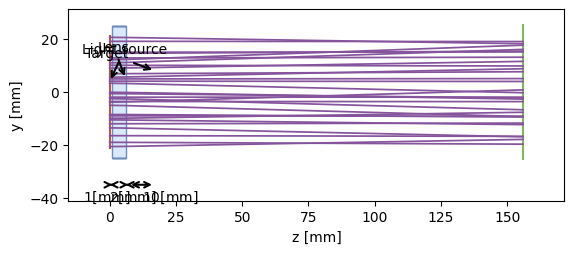

In [ ]:
from diffinytrace import (
    source, transforms, Bspline, Plane, Lens, Detector, SequentialOpticalSystem,
    utils, plotting, target_grid, render, minimize, set_unused_bspline_coeff_to_nearest,
    export, gaussian_smoother
)
from typing import List 
aperture_radius_source:float=21.
aperture_radius_lens:float=25.
lens_thickness:float=5.
detector_distance:float=150.
lens_distance:float=1.0
num_refinements:int=5
image_padding:float=0.2
bspline_orders:List[int]=[3, 3]
bspline_ns_start:List[int]=[4, 4]

lens_thickness: float = 5.0

lens_material=dit.materials["PMMA"]
air_material=dit.materials["AIR"]
light_transform = transforms.Offset(torch.tensor([0.0,0.0,0.0]))
light_transform.pos.requires_grad = False

light_source = None
    
light_source = source.VisibleSunlightSimpleMonochromatic(light_transform,aperture_radius_source,wl=0.5,total_power=1.0,theta_max_rad=theta_max_rad)
lens_transform = transforms.Distance(lens_distance,parent_transform=light_transform)

aperture_radius_detector = aperture_radius_source*(1+image_padding)
    
bspline_surface1 = Bspline(aperture_radius_lens,orders,ns_start)
           
surface1 = Plane()
lens1 = Lens(lens_transform,lens_thickness,surface1,bspline_surface1,lens_material,aperture_radius_lens,is_square=True)
lens_transform.distance.requires_grad = False
lens1.lens_thickness.requires_grad = False
detector_transform = transforms.Distance(detector_distance,parent_transform=lens1)#25.0+0.5
detector_transform.distance.requires_grad = False
plane_surface = Plane()
detector = Detector(detector_transform,plane_surface,aperture_radius_detector)
system = SequentialOpticalSystem({"source":light_source,"lens":lens1,"detector":detector},air_material)
sequence = ["source","lens","detector"]

x,weights = light_source.sample(30)
O,D,wave_len,_,RayPaths = system(x,sequence)

system.to("cpu")
offset_arrows = -(aperture_radius_lens+10)
dit.plotting.system2D.plot(system,RayPaths,500,show = False)
dit.plotting.system2D.annotated_arrow([0,offset_arrows],[1,offset_arrows],(-20,-12),"$1$[mm]","<->")
dit.plotting.system2D.annotated_arrow([1,offset_arrows],[1+lens_thickness,offset_arrows],(-12,-12),"$2$[mm]","<->")
dit.plotting.system2D.annotated_arrow([5+2,offset_arrows],[1+lens_thickness,offset_arrows],(0,-12),"$10$[mm]","<->")
dit.plotting.system2D.annotate_position([0,4],(-20,20),"Light source")
dit.plotting.system2D.annotate_position([5+1,5],(-20,20),"Lens")
dit.plotting.system2D.annotate_position([5+2+10,8],(-50,10),"Target")


In [ ]:
#import os
#os.kill(os.getpid(), 9)